In [1]:
import sys
import torch
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms

In [2]:
cwd = Path.cwd()
project_root = cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("done!")

done!


In [3]:
transformation = transforms.Compose([transforms.ToTensor()])

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [5]:
train_dataset = datasets.MNIST(
    root=project_root / "data",
    train=True,
    transform=transformation,
    download=True
)

In [6]:
test_dataset = datasets.MNIST(
    root=project_root / "data",
    train=False,
    transform=transformation,
    download=True
)

In [7]:
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [8]:
for img, label in train_dataloader:
    print(f"Label: {label}, shape: {label.shape}")
    print(f"img: {img}, shape: {img.shape}")
    break

Label: tensor([2, 8, 3, 7, 0, 0, 4, 0, 0, 2, 7, 0, 1, 6, 0, 8, 5, 1, 0, 3, 4, 5, 7, 6,
        7, 2, 7, 8, 3, 3, 3, 3, 1, 9, 0, 1, 0, 9, 2, 0, 4, 9, 2, 4, 0, 4, 7, 0,
        3, 9, 3, 3, 7, 5, 0, 0, 7, 5, 9, 3, 0, 4, 8, 1, 7, 9, 1, 5, 9, 2, 7, 9,
        5, 3, 0, 5, 0, 7, 5, 2, 1, 0, 9, 6, 3, 6, 1, 7, 1, 6, 5, 1, 3, 5, 1, 7,
        6, 0, 7, 5, 7, 2, 6, 1, 0, 5, 6, 3, 1, 9, 4, 1, 3, 6, 9, 3, 1, 2, 6, 2,
        9, 0, 1, 4, 8, 3, 0, 4]), shape: torch.Size([128])
img: tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 

### Let's build the encoder

In [11]:
class Encoder(nn.Module):
    def __init__(self, in_channels, D):
        super().__init__()
        self.conv_layer1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=4*D,
            kernel_size=4,
            stride=2,
            padding=1
        )
        self.conv_layer2 = nn.Conv2d(
            in_channels=4*D,
            out_channels=2*D,
            kernel_size=4,
            stride=2,
            padding=1,
        )
        self.conv_layer3 = nn.Conv2d(
            in_channels=2*D,
            out_channels=D,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.relu = nn.ReLU()
        
    def forward(self, X):
        X = self.conv_layer1(X)
        X = self.relu(X)
        X = self.conv_layer2(X)
        X = self.relu(X)
        X = self.conv_layer3(X)
        return X

### Building the CodeBook

In [58]:
a = torch.randint(low=0, high=5, size=[10])
a

tensor([1, 2, 1, 2, 0, 2, 4, 2, 3, 4])

In [59]:
b = torch.randn(size=[5,4])
b

tensor([[ 0.3435,  0.6824,  0.4446,  0.1129],
        [ 0.5354, -0.4103,  0.7632,  0.0582],
        [ 0.8960, -1.6360,  0.3892, -1.6605],
        [-1.8089, -1.2219, -0.3798, -0.2782],
        [-1.1940, -0.8104,  0.8754, -1.7418]])

In [60]:
b[a]

tensor([[ 0.5354, -0.4103,  0.7632,  0.0582],
        [ 0.8960, -1.6360,  0.3892, -1.6605],
        [ 0.5354, -0.4103,  0.7632,  0.0582],
        [ 0.8960, -1.6360,  0.3892, -1.6605],
        [ 0.3435,  0.6824,  0.4446,  0.1129],
        [ 0.8960, -1.6360,  0.3892, -1.6605],
        [-1.1940, -0.8104,  0.8754, -1.7418],
        [ 0.8960, -1.6360,  0.3892, -1.6605],
        [-1.8089, -1.2219, -0.3798, -0.2782],
        [-1.1940, -0.8104,  0.8754, -1.7418]])

In [61]:
b.argmin(dim=1)

tensor([3, 1, 3, 0, 3])

In [12]:
class CodeBook(nn.Module):
    def __init__(self, K, D):
        super().__init__()
        self.embedding = nn.Embedding(K, D)
    
    def forward(self, X:torch.tensor):
        shape = X.shape
        X = torch.reshape(X, [-1, self.embedding.weight.shape[1]])
        distances = (X**2).sum(dim=1, keepdim=True) + ((self.embedding.weight**2).sum(dim=1, keepdim=True)).T - 2*(X @ self.embedding.weight.T)
        min_dis_ind = distances.argmin(dim=1)
        zq = self.embedding.weight[min_dis_ind]
        zq_straight = X + (zq - X).detach()
        return zq_straight.reshape(shape), zq.reshape(shape)

### Let's Build The Decoder

In [13]:
class Decoder(nn.Module):
    def __init__(self, D):
        super().__init__()
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.inv_conv_layer1 = nn.ConvTranspose2d(
            in_channels=D,
            out_channels=2*D,
            kernel_size=3,
            padding=1,
            stride=1,
        )
        self.inv_conv_layer2 = nn.ConvTranspose2d(
            in_channels=2*D,
            out_channels=4*D,
            kernel_size=4,
            stride=2,
            padding=1,
        )
        self.inv_conv_layer3 = nn.ConvTranspose2d(
            in_channels=4*D,
            out_channels=1,
            kernel_size=4,
            stride=2,
            padding=1,
        )
        
    def forward(self, X):
        X = self.inv_conv_layer1(X)
        X = self.relu(X)
        X = self.inv_conv_layer2(X)
        X = self.relu(X)
        X = self.inv_conv_layer3(X)
        X = self.sigmoid(X)
        return X

## Let's combine everything and build the VQ_VAE

In [14]:
class VQ_VAE(nn.Module):
    def __init__(self, in_channels, D, K):
        super().__init__()
        self.encoder = Encoder(in_channels, D)
        self.codebook = CodeBook(K, D)
        self.decoder = Decoder(D)
        
    def forward(self, X):
        ze = self.encoder(X)
        zq_straight, zq_raw = self.codebook(ze)
        generated_img = self.decoder(zq_straight)
        return generated_img, ze, zq_raw

### Cost Function

In [15]:
def cost_fn(
    original_img,
    generated_img,
    ze,
    zq,
    beta: float = 0.25
):
    # reconstruction error
    term1 = F.binary_cross_entropy(generated_img, original_img)
    
    # codebook loss
    term2 = ((ze.detach() - zq)**2).mean()
    
    # commitment loss
    term3 = ((ze - zq.detach())**2).mean()
    
    # print(f"term 1: {term1}")
    # print(f"term 2: {term2}")
    # print(f"term 3: {term3}")
    
    loss = term1 + term2 + beta*term3
    
    return loss

### Let's Write the Training Function

In [16]:
def train(model:VQ_VAE, dataloader: DataLoader, optimizer, epochs: int):
    for i in range(epochs):
        total_loss = 0
        for batch in dataloader:
            img, _  = batch
            
            # forward pass
            generated_img, ze, zq = model.forward(img)
            # calculating loss
            loss = cost_fn(
                original_img=img,
                generated_img=generated_img,
                ze=ze,
                zq=zq
            )
            # total loss
            total_loss += loss
            # zero the gradients
            optimizer.zero_grad()
            # backward pass
            loss.backward()
            # update weights
            optimizer.step()
            
        avg_loss = total_loss/len(dataloader)
        print(f"Epoch {i+1}: Loss: {avg_loss.item():.2f}")
        
    return model

## Let's Train our VQ_VAE model

In [87]:
D = 32
K = 128
model = VQ_VAE(in_channels=1, D=D, K=K)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
trained_model = train(
    model=model,
    dataloader=train_dataloader,
    optimizer=optimizer,
    epochs=10
)

Epoch 1: Loss: 1.01
Epoch 2: Loss: 0.89
Epoch 3: Loss: 0.82
Epoch 4: Loss: 0.77
Epoch 5: Loss: 0.73
Epoch 6: Loss: 0.69
Epoch 7: Loss: 0.66
Epoch 8: Loss: 0.63
Epoch 9: Loss: 0.60
Epoch 10: Loss: 0.57


### Let's check the reconstruction

In [100]:
def visualize_reconstructions(model, dataloader, n=10):
    # Switching to eval mode
    model.eval()
    
    with torch.no_grad():
        figs, axes = plt.subplots(nrows=2, ncols=n, figsize=(12,3))
        # getting one batch
        original_imgs, _ = next(iter(dataloader))
        # inference
        generated_imgs, _, _ = model.forward(original_imgs)
        
        for i in range(n):
            axes[0, i].imshow(original_imgs[i].squeeze(), cmap='gray')
            axes[0, i].axis('off')
            
            axes[1, i].imshow(generated_imgs[i].squeeze(), cmap='gray')
            axes[1, i].axis('off')
            
        plt.show()

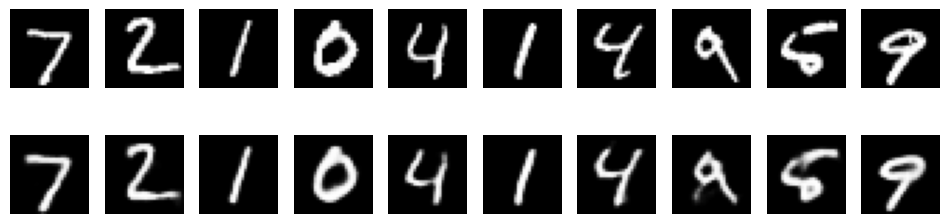

In [103]:
visualize_reconstructions(
    model=model,
    dataloader=test_dataloader,
    n=10
)

### Saving the model

In [9]:
model_weigths_path = project_root / "data" / "vqvae_mnist.pth"

In [ ]:
torch.save(model.state_dict(), str(model_weigths_path))

### Loading and Testing generation

In [18]:
D = 32
K = 128
model = VQ_VAE(in_channels=1, D=D, K=K)
model.load_state_dict(torch.load(str(model_weigths_path)))
model.eval()

VQ_VAE(
  (encoder): Encoder(
    (conv_layer1): Conv2d(1, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv_layer2): Conv2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv_layer3): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
  )
  (codebook): CodeBook(
    (embedding): Embedding(128, 32)
  )
  (decoder): Decoder(
    (relu): ReLU()
    (sigmoid): Sigmoid()
    (inv_conv_layer1): ConvTranspose2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (inv_conv_layer2): ConvTranspose2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (inv_conv_layer3): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  )
)

### Let's visualize some stuff

Let's visulize the embedding vectors, To do that we can simply choose one vector from the embedding space and pass it through the decoder

In [26]:
np.random.randint(low=0, high=K-1, size=1)

array([8], dtype=int32)

In [27]:
random_feature = model.codebook.embedding.weight[np.random.randint(low=0, high=K-1, size=1).item()]
random_feature.shape

torch.Size([32])

In [35]:
# transforming to the expected shaped for decoder
a = torch.ones(size=[D, 7, 7])
a.shape

torch.Size([32, 7, 7])

In [ ]:
random_feature = random_feature.unsqueeze(dim=1)
random_feature = random_feature.unsqueeze(dim=1)

In [43]:
random_feature.shape

torch.Size([32, 1, 1])

In [44]:
b = random_feature * a
b

tensor([[[-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115],
         [-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115],
         [-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115],
         ...,
         [-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115],
         [-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115],
         [-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115]],

        [[-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683],
         [-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683],
         [-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683],
         ...,
         [-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683],
         [-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683],
         [-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683]],

        [[ 1.9940,  1.9940,  1.9940,  ...,  1.9940,  1.9940,  1.9940],
         [ 1.9940,  1.9940,  1.9940,  ...,  1

In [45]:
b = b.unsqueeze(dim=0)

In [46]:
b.shape

torch.Size([1, 32, 7, 7])

In [69]:
def visualize_codebook(model:VQ_VAE, K, D, n=64):
    if n > K:
        raise ValueError(f"n should be less than or equal {K}")
    model.eval()
    
    with torch.no_grad():
        figs, axes = plt.subplots(nrows=8, ncols=8, figsize=(8,8))
        
        for i in range(n):
            feature = model.codebook.embedding.weight[i]
            ones_vec = torch.ones(size=[D, 7, 7])
            feature = feature.unsqueeze(dim=1)
            feature = feature.unsqueeze(dim=1)
            dec_input = feature * ones_vec
            generated_feature = model.decoder.forward(dec_input)
            generated_feature = generated_feature.squeeze()
            
            row = i // 8
            col = i % 8
            axes[row, col].imshow(generated_feature, cmap='gray')
            axes[row, col].axis('off')
        
        plt.show()

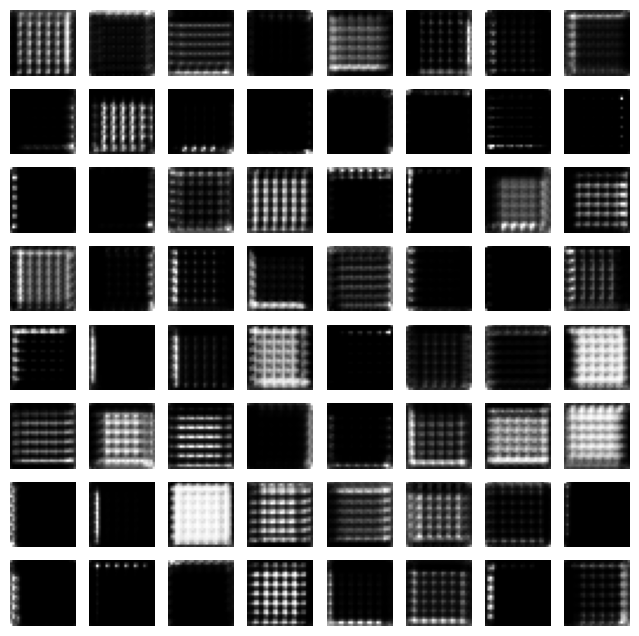

In [70]:
visualize_codebook(
    model=model,
    K=K,
    D=D,
)

In [ ]:
def visualize_codebook_activation(model: VQ_VAE, dataloader: DataLoader):
    model.eval()
    
    with torch.no_grad():
        imgs, labels = next(iter(dataloader))
        img = imgs[0].unsqueeze(0)
        
        # passing through the encoder
        ze = model.encoder.forward(img)
        
        